<a href="https://colab.research.google.com/github/vansh-wise/DATA-SCIENCE01/blob/main/ds__assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You have been hired by a rookie movie producer to help him decide what type of movies to produce and which actors to cast. You have to back your recommendations based on thorough analysis of the data he shared with you which has the list of 3000 movies and the corresponding details.
As a data scientist, you have to first explore the data and check its sanity.

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
df = pd.read_csv('imdb_data (1).csv')
def parse_json(x):
    try:
        return ast.literal_eval(x) if pd.notna(x) and x != '' else []
    except:
        return []
df['genres_parsed'] = df['genres'].apply(parse_json)
df['prod_companies'] = df['production_companies'].apply(parse_json)
df['cast_parsed'] = df['cast'].apply(parse_json)
df['crew_parsed'] = df['crew'].apply(parse_json)
df['profit'] = df['revenue'] - df['budget']
df['roi'] = np.where(df['budget'] > 0, df['profit']/df['budget'], 0)

In [ ]:
df.shape

(3000, 29)

**QUESTION 1**


**Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.**


In [ ]:
# Highest profit movie
highest_profit_idx = df["profit"].idxmax()
highest_profit_movie = df.iloc[highest_profit_idx]
print("HIGHEST PROFIT MOVIE")
print(f"Title: {highest_profit_movie['title']}")
print(f"Profit: ${highest_profit_movie['profit']:,.0f}")
print(f"ROI: {highest_profit_movie['roi']:.2%}")
producers = [comp['name'] for comp in highest_profit_movie["prod_companies"]]
print(f"\nProducers: {', '.join(producers)}")
director = next((person['name'] for person in highest_profit_movie["crew_parsed"]
                if person.get('job') == 'Director'), 'N/A')
print(f"Director: {director}")
actors = [person['name'] for person in highest_profit_movie["cast_parsed"][:3]]
print(f"Top Actors: {', '.join(actors)}")

HIGHEST PROFIT MOVIE
Title: Furious 7
Profit: $1,316,249,360
ROI: 692.76%

Producers: Universal Pictures, Original Film, Fuji Television Network, Dentsu, One Race Films, China Film Co., Québec Production Services Tax Credit, Media Rights Capital (MRC), Abu Dhabi Film Commission, Colorado Office of Film, Television & Media
Director: James Wan
Top Actors: Vin Diesel, Paul Walker, Dwayne Johnson


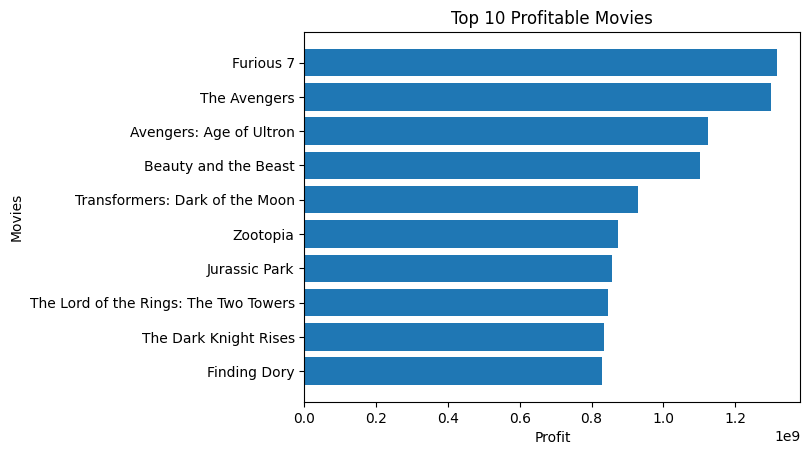

In [ ]:
top_profit_movies = df.sort_values(by="profit", ascending=False).head(10)
plt.figure()
plt.barh(top_profit_movies["title"], top_profit_movies["profit"])
plt.title("Top 10 Profitable Movies")
plt.xlabel("Profit")
plt.ylabel("Movies")
plt.gca().invert_yaxis()
plt.show()

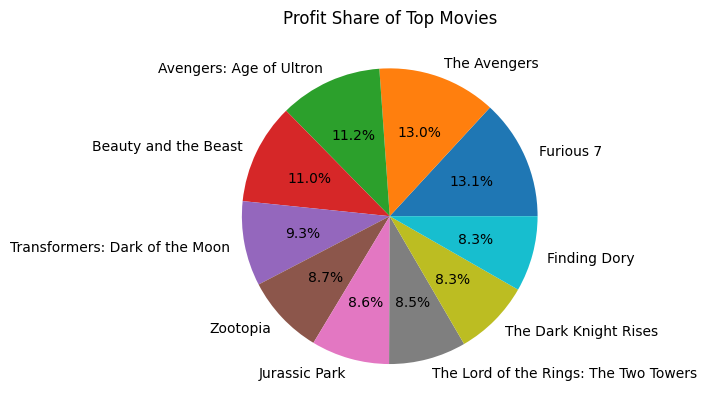

In [ ]:
plt.figure()
plt.pie(top_profit_movies["profit"], labels=top_profit_movies["title"], autopct='%1.1f%%')
plt.title("Profit Share of Top Movies")
plt.show()

**QUESTION 2**

**This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?**

In [ ]:
# Average ROI
lang_roi = df.groupby("original_language")["roi"].agg(['mean', 'count']).reset_index()
lang_roi = lang_roi[lang_roi['count'] >= 2]
lang_roi = lang_roi.sort_values("mean", ascending=False)
print("LANGUAGE WITH HIGHEST AVERAGE ROI")
print(lang_roi.head())
print(f"\n Winner: {lang_roi.iloc[0]['original_language']}")
print(f"Average ROI: {lang_roi.iloc[0]['mean']:.2%}")


LANGUAGE WITH HIGHEST AVERAGE ROI
   original_language           mean  count
18                ko  209986.756254     20
7                 en    4104.728457   2575
31                te       4.400768      2
24                pl       3.958170      2
19                ml       3.708333      2

 Winner: ko
Average ROI: 20998675.63%


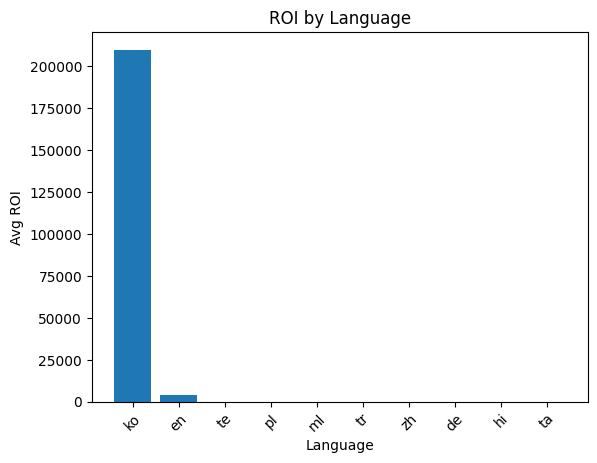

In [ ]:
top_lang = lang_roi.head(10)
plt.figure()
plt.bar(top_lang["original_language"], top_lang["mean"])
plt.title("ROI by Language")
plt.xlabel("Language")
plt.ylabel("Avg ROI")
plt.xticks(rotation=45)
plt.show()

**QUESTION 3**

**Find out the unique genres of movies in this dataset.**

In [ ]:
all_genres = [g['name'] for genres in df['genres_parsed'] for g in genres]
unique_genres = sorted(list(set(all_genres)))
print(f"Total: {len(unique_genres)} genres")
print(unique_genres[:10], "...")
print()

Total: 20 genres
['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign'] ...



20 ['Animation', 'Drama', 'Documentary', 'History', 'Fantasy', 'War', 'Music', 'Horror', 'Comedy', 'Western']


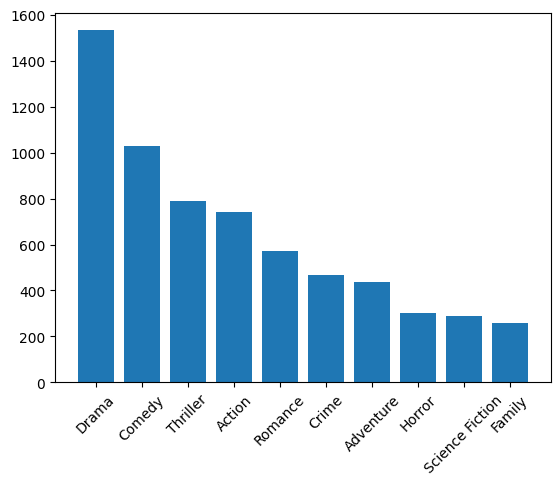

In [ ]:
genres = [g['name'] for sub in df['genres_parsed'] for g in sub]
unique_genres = list(set(genres))
print(len(unique_genres), unique_genres[:10])
genre_df = pd.DataFrame(genres, columns=["genre"])
top_genres = genre_df["genre"].value_counts().head(10)
plt.bar(top_genres.index, top_genres.values)
plt.xticks(rotation=45)
plt.show()

**QUESTION 4**

**Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?**

In [ ]:
df["producer_names"] = df["prod_companies"].apply(
    lambda x: [comp['name'] for comp in x]
)
table_sample = df[["title", "prod_companies", "crew_parsed", "roi"]].head()
print("Producer-Director Table (Sample):")
for idx, row in table_sample.iterrows():
    producers = [p['name'] for p in row["prod_companies"]]
    director = next((c['name'] for c in row["crew_parsed"] if c.get('job') == 'Director'), 'N/A')
    print(f"{row['title']}: Producers={producers[:2]}, Director={director}")
# producers by average ROI
producer_roi = []
for idx, row in df.iterrows():
    for producer in row["producer_names"]:
        producer_roi.append({"producer": producer, "roi": row["roi"], "movie": row["title"]})

producer_df = pd.DataFrame(producer_roi)
print("\nTOP 3 PRODUCERS BY AVERAGE ROI:")
if not producer_df.empty:
    top_producers = (
        producer_df.groupby("producer")["roi"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(3)
    )
    for i, (producer, avg_roi) in enumerate(top_producers.items(), 1):
        print(f"{i}. {producer}: {avg_roi:.2%}")
else:
    print("No producer data found to calculate average ROI.")


Producer-Director Table (Sample):
Hot Tub Time Machine 2: Producers=['Paramount Pictures', 'United Artists'], Director=Steve Pink
The Princess Diaries 2: Royal Engagement: Producers=['Walt Disney Pictures'], Director=Garry Marshall
Whiplash: Producers=['Bold Films', 'Blumhouse Productions'], Director=Damien Chazelle
Kahaani: Producers=[], Director=Sujoy Ghosh
Marine Boy: Producers=[], Director=Jong-seok Yoon

TOP 3 PRODUCERS BY AVERAGE ROI:
1. Charles Chaplin Productions: 425000400.00%
2. Film It Suda: 209873781.25%
3. Lions Gate: 99999900.00%


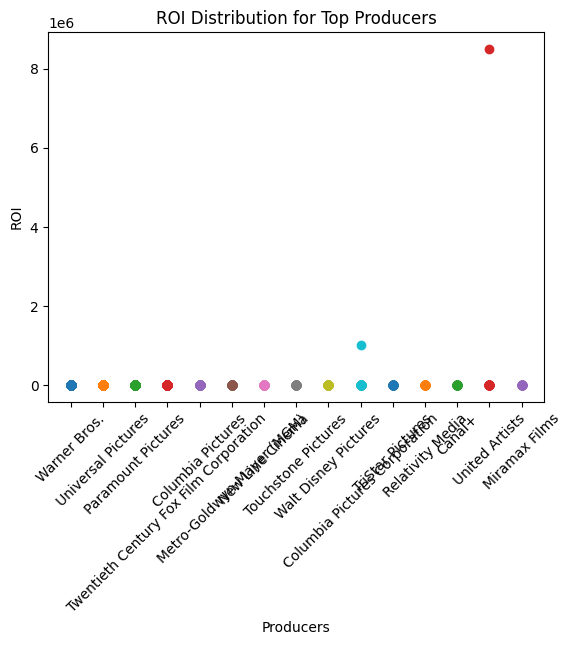

In [ ]:
# graph of producers
top_producers_list = producer_df["producer"].value_counts().head(15).index
filtered_df = producer_df[producer_df["producer"].isin(top_producers_list)]
plt.figure()
for producer in top_producers_list:
    subset = filtered_df[filtered_df["producer"] == producer]
    plt.scatter([producer]*len(subset), subset["roi"])
plt.title("ROI Distribution for Top Producers")
plt.xlabel("Producers")
plt.ylabel("ROI")
plt.xticks(rotation=45)
plt.show()

**QUESTION 5**

**Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.**

In [ ]:
actors = [p['name'] for sub in df["cast_parsed"] for p in sub]
actor_df = pd.DataFrame(actors, columns=["actor"])
top_actor = actor_df["actor"].value_counts().idxmax()
print(top_actor)
profits = []
for _, row in df.iterrows():
    if any(p['name'] == top_actor for p in row["cast_parsed"]):
        profits.append(row["profit"])

Samuel L. Jackson


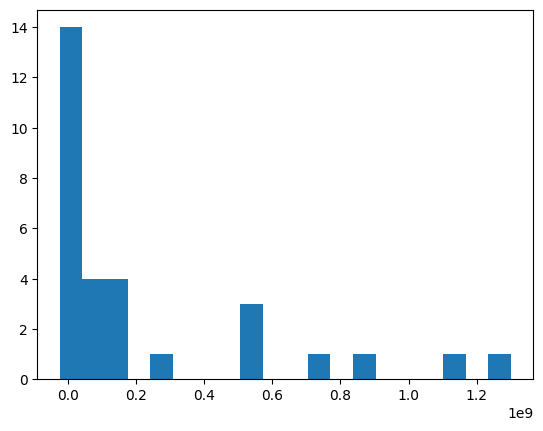

In [ ]:
plt.hist(profits, bins=20)
plt.show()

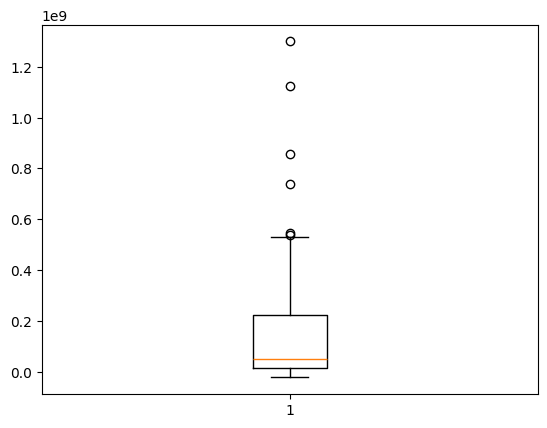

In [ ]:
plt.boxplot(profits)
plt.show()

**QUESTION 6**

**Top 3 directors prefer which actors the most?**

In [ ]:
#top 3 directors
data = []
for _, row in df.iterrows():
    director = next((p['name'] for p in row["crew_parsed"] if p.get('job') == 'Director'), None)
    if director:
        data.append([director, row["roi"]])

director_df = pd.DataFrame(data, columns=["director", "roi"])
top_dirs = (
    director_df.groupby("director")["roi"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
)
for director in top_dirs.index:
    actors = []

    for _, row in df.iterrows():
        d = next((p['name'] for p in row["crew_parsed"] if p.get('job') == 'Director'), None)
        if d == director:
            actors.extend([p['name'] for p in row["cast_parsed"]])

    unique_actors = list(set(actors))
    actor_counts = []

    for a in unique_actors:
        count = actors.count(a)
        actor_counts.append([a, count])

    actor_counts.sort(key=lambda x: x[1], reverse=True)

    print(director)
    print(actor_counts[:3])

Park Kwang-hyun
[['Jung Jae-young', 1], ['Kang Hye-jung', 1], ['Yoo Seung-mok', 1]]
Charlie Chaplin
[['Charlie Chaplin', 3], ['Paulette Goddard', 2], ['Richard Alexander', 2]]
Douglas Aarniokoski
[['Judd Nelson', 1], ['Paz de la Huerta', 1], ['Katrina Bowden', 1]]


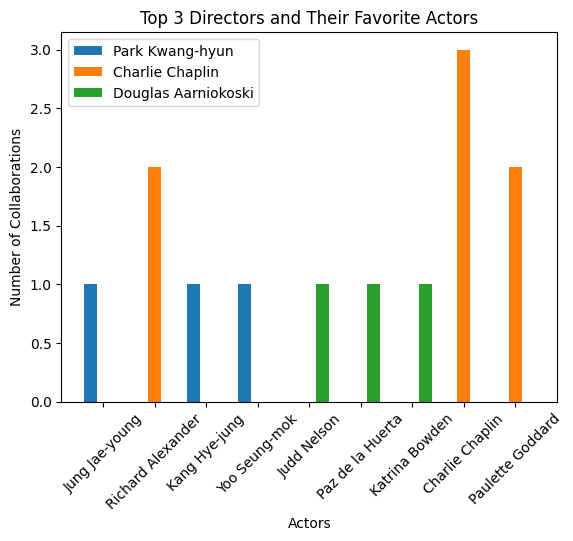

In [ ]:
all_actors = list(set(actor for d in director_actor_data.values() for actor in d))
data_matrix = []
for director in director_actor_data:
    row = []
    for actor in all_actors:
        row.append(director_actor_data[director].get(actor, 0))
    data_matrix.append(row)
#graph
x = np.arange(len(all_actors))
width = 0.25
for i, director in enumerate(director_actor_data.keys()):
    plt.bar(x + i*width, data_matrix[i], width, label=director)
plt.xticks(x + width, all_actors, rotation=45)
plt.xlabel("Actors")
plt.ylabel("Number of Collaborations")
plt.title("Top 3 Directors and Their Favorite Actors")
plt.legend()

plt.show()